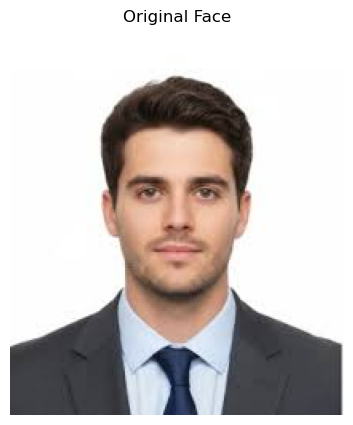

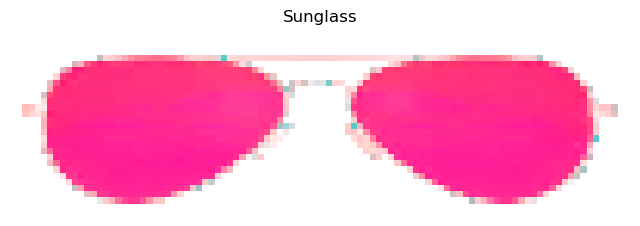

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.0].


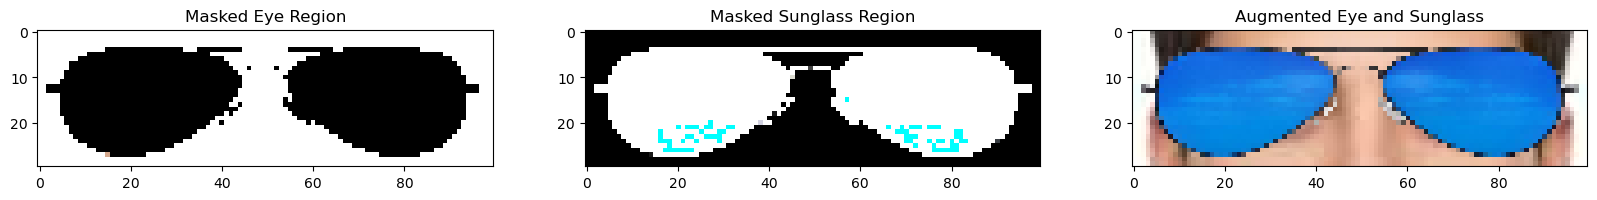

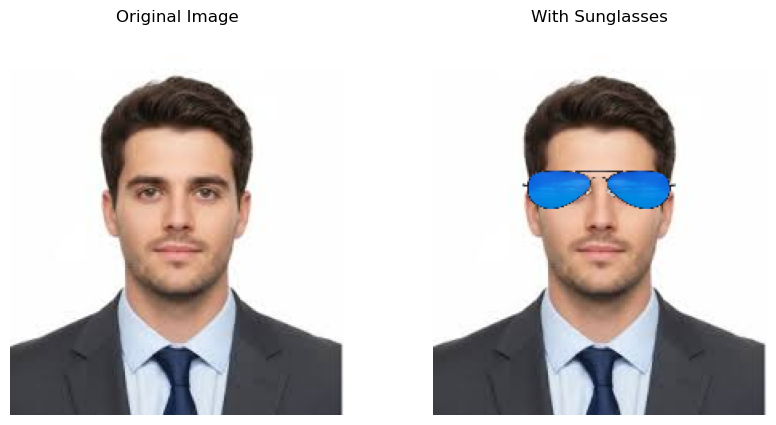

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Images
faceImage = cv2.imread("download.jpg")
glassPNG = cv2.imread("sunglass.png", cv2.IMREAD_UNCHANGED)

# Show Original Face
plt.figure(figsize=(5,5))
plt.imshow(faceImage[:,:,::-1])
plt.title("Original Face")
plt.axis("off")
plt.show()

# Resize Glass (center fit)
glassPNG = cv2.resize(glassPNG,(100,30))

# Show Glass
plt.figure(figsize=(8,3))
plt.imshow(glassPNG[:,:,::-1])
plt.title("Sunglass")
plt.axis("off")
plt.show()

# Separate Color and Alpha
glassBGR = glassPNG[:,:,:3]

glassMask = glassPNG[:,:,3] / 255.0
glassMask = np.dstack([glassMask,glassMask,glassMask])

# Face dimensions
H,W = faceImage.shape[:2]

# Center Position
glass_h, glass_w = glassBGR.shape[:2]

x1 = (W - glass_w)//2
y1 = int(H*0.35)

x2 = x1 + glass_w
y2 = y1 + glass_h

# Eye ROI
eyeROI = faceImage[y1:y2,x1:x2]

# Blend
maskedEye = cv2.multiply(
    eyeROI.astype(np.float32),
    (1-glassMask).astype(np.float32)
)

maskedGlass = cv2.multiply(
    glassBGR.astype(np.float32),
    glassMask.astype(np.float32)
)

eyeRoiFinal = cv2.add(maskedEye,maskedGlass)
eyeRoiFinal = eyeRoiFinal.astype(np.uint8)

# Intermediate Results
plt.figure(figsize=[20,20])

plt.subplot(131)
plt.imshow(maskedEye[:,:,::-1])
plt.title("Masked Eye Region")

plt.subplot(132)
plt.imshow(maskedGlass[:,:,::-1])
plt.title("Masked Sunglass Region")

plt.subplot(133)
plt.imshow(eyeRoiFinal[:,:,::-1])
plt.title("Augmented Eye and Sunglass")

plt.show()

# Final Output
faceWithGlasses = faceImage.copy()
faceWithGlasses[y1:y2,x1:x2] = eyeRoiFinal

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(faceImage[:,:,::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(faceWithGlasses[:,:,::-1])
plt.title("With Sunglasses")
plt.axis("off")

plt.show()